[[2000.         2000.47899687 2000.95799373 ... 2285.9611294
  2286.44012627 2286.91912313]
 [1985.         1985.49398937 1985.98796375 ... 2277.70422125
  2278.1914709  2278.6787123 ]
 [1970.         1970.50898187 1971.01793377 ... 2269.44731311
  2269.94281554 2270.43830147]
 ...
 [ 545.          546.93326961  548.86508567 ... 1485.04103915
  1486.32055578 1487.59927229]
 [ 530.          531.94826211  533.89505569 ... 1476.784131
  1478.07190042 1479.35886146]
 [ 515.          516.96325461  518.92502571 ... 1468.52722286
  1469.82324505 1471.11845063]]


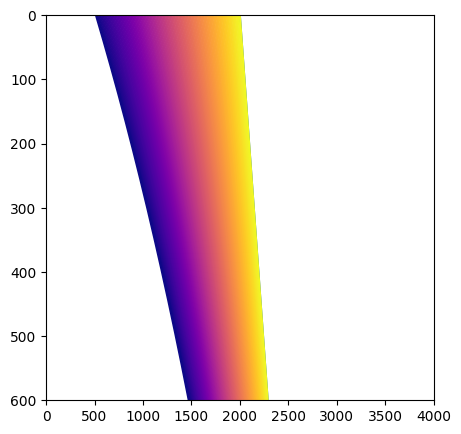

In [26]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


g = 9.81 #m.s^-2
pi = np.pi


def Alpha_T(P,T):
	''' T in Kelvin, P in GPa'''
	b0 = 1.345e11 # in Pa
	b1 = -2.23e7 #Pa.K^-1
	
	Kprime0_T = 5.37
	a0 = 3.034e-5 # K^-1
	a1 = 7.422e-9 # K^-2
	a2 = -0.5381 # K

	del_t = 5.5

	alpha0_T = a0 + a1*T + a2*(T**-2)

	K0_T = b0 + b1*T
	C = 5-((3/2)*(4-Kprime0_T))
	Vpt_V0 = (1+(2/C)*(-0.5+np.sqrt(0.25+((P*(1e9)*C)/(3*K0_T)))))**(-3/2)

	alpha_PT = alpha0_T * (Vpt_V0**del_t)

	return alpha0_T, K0_T, C, Vpt_V0, alpha_PT


def adiabat(T0, alpha_T = 2.9e-5, Cp = 1350):
	z = np.arange(0,600, 1)
	rho_z = 3300  # kg.m^-3
	P_z = rho_z * g * z * 1e-6 # in GPa
	T_ad = (T0+273) * (1 + ((alpha_T)*g*(z*10**3))/Cp)
	return(T_ad-273, z, P_z)

def cool_adiabat(depth_array,T_profile, dt=1, time_steps = 100, cool_rate_surface = 15, plot = False, axes = None):
	T_evolution = np.zeros((time_steps,len(depth_array)))
	T_evolution[0] = T_profile

	depth_factor = np.exp(-depth_array / 1000)
	cooling_rate = cool_rate_surface * depth_factor

	for t in range(1,time_steps):
		T_evolution[t] = T_evolution[t-1] - (cooling_rate * dt)

	print(T_evolution)

	if plot and axes is not None:
		color_values = [T_evolution[i,0] for i in range(time_steps)]
		#print(f"Average = {np.average(color_values)} +- {2*np.std(color_values)}")
		min_val = min(color_values)
		max_val = max(color_values)

		cmap = plt.get_cmap('plasma')  # You can try other colormaps like 'plasma', 'magma', etc.
		norm = plt.Normalize(min_val, max_val)
		for i in range(time_steps):
			if i % 10 == 0:
				axes.plot(T_evolution[i,:],depth_array, color = cmap(norm(color_values[i])))

	return T_evolution


fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111)

T, Z, Pz = adiabat(2000)

ax.plot(T,Z)
cool_adiabat(Z,T, plot = True, axes = ax)

ax.set_xlim(0,4000)
ax.set_ylim(600,0)
plt.show()

